# Week 3: Preprocessing and Data Leakage on Adult Income

## Goal

Demonstrate two common forms of leakage with the local `adult_with_marker.csv` dataset:

1. fitting preprocessing on the full dataset before the train/test split; and
2. using `income_marker`, a feature derived directly from the target.

These flawed workflows are compared with a valid scikit-learn pipeline that learns every preprocessing parameter from the training rows only.

## Setup

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42
TEST_SIZE = 0.30

## Steps

### 1. Load and inspect the leakage marker

In [2]:
candidate_paths = [Path("adult_with_marker.csv"), Path("Week 3") / "adult_with_marker.csv"]
DATA_PATH = next((path for path in candidate_paths if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError(
        "adult_with_marker.csv was not found beside the notebook or under Week 3/"
    )

adult = pd.read_csv(DATA_PATH)
adult.columns = adult.columns.str.strip()
object_columns = adult.select_dtypes(include="object").columns
adult[object_columns] = adult[object_columns].apply(lambda column: column.str.strip())
adult[object_columns] = adult[object_columns].replace("?", np.nan)

print(f"Source: {DATA_PATH.resolve()}")
print(f"Rows: {adult.shape[0]:,} | Columns: {adult.shape[1]}")
display(adult.head())

Source: D:\Programming\SEM-5 ML labs\Week 3\adult_with_marker.csv
Rows: 152 | Columns: 16


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income,income_marker
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K,0
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K,0
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K,0
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K,0
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K,0


In [3]:
y = adult["income"].eq(">50K").astype(int).rename("income_gt_50k")
marker_check = pd.crosstab(
    y,
    adult["income_marker"],
    rownames=["Encoded income target"],
    colnames=["income_marker"],
)
marker_agreement = adult["income_marker"].eq(y).mean()

display(marker_check)
print(f"Marker/target agreement: {marker_agreement:.1%}")

income_marker,0,1
Encoded income target,,
0,77,0
1,0,75


Marker/target agreement: 100.0%


`income_marker` matches the encoded target row-for-row. It is therefore not a legitimate predictor: supplying it to a model is equivalent to revealing the answer.

### 2. Create one shared train/test split

In [4]:
# Valid predictors exclude both the target and its leaked copy.
X = adult.drop(columns=["income", "income_marker"])
X_with_marker = adult.drop(columns="income")

all_indices = np.arange(len(adult))
train_indices, test_indices = train_test_split(
    all_indices,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train = X.iloc[train_indices].copy()
X_test = X.iloc[test_indices].copy()
y_train = y.iloc[train_indices].copy()
y_test = y.iloc[test_indices].copy()

print(f"Training rows: {len(train_indices)} | Test rows: {len(test_indices)}")
print(f"Positive-class rate — train: {y_train.mean():.3f}, test: {y_test.mean():.3f}")

Training rows: 106 | Test rows: 46
Positive-class rate — train: 0.491, test: 0.500


### 3. Define reusable preprocessing

In [5]:
def make_preprocessor(features):
    numeric_features = features.select_dtypes(include=np.number).columns.tolist()
    categorical_features = features.select_dtypes(exclude=np.number).columns.tolist()

    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, numeric_features),
            ("categorical", categorical_pipeline, categorical_features),
        ]
    )


def evaluate(name, truth, predicted, probability):
    return {
        "Workflow": name,
        "Accuracy": accuracy_score(truth, predicted),
        "Precision": precision_score(truth, predicted, zero_division=0),
        "Recall": recall_score(truth, predicted, zero_division=0),
        "F1": f1_score(truth, predicted, zero_division=0),
        "ROC AUC": roc_auc_score(truth, probability),
    }

### 4. Flawed workflow: preprocess before splitting

The preprocessor below learns medians, category vocabularies, and scaling statistics from all rows, including the future test rows. The labels are not used, but the held-out feature distribution has contaminated model development.

In [6]:
leaky_preprocessor = make_preprocessor(X)
X_preprocessed_all = leaky_preprocessor.fit_transform(X)  # Deliberate leakage

leaky_model = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
leaky_model.fit(X_preprocessed_all[train_indices], y_train)
leaky_predictions = leaky_model.predict(X_preprocessed_all[test_indices])
leaky_probabilities = leaky_model.predict_proba(X_preprocessed_all[test_indices])[:, 1]

### 5. Correct workflow: split first, then fit a pipeline

The pipeline is fitted only on `X_train`. During prediction, it applies those training-derived transformations to `X_test` without relearning anything from the test rows.

In [7]:
correct_pipeline = Pipeline(
    steps=[
        ("preprocess", make_preprocessor(X_train)),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]
)
correct_pipeline.fit(X_train, y_train)
correct_predictions = correct_pipeline.predict(X_test)
correct_probabilities = correct_pipeline.predict_proba(X_test)[:, 1]

### 6. Severe target leakage: include `income_marker`

This pipeline is mechanically correct, but its inputs are not. `income_marker` was created from `income`, so the model sees the target at prediction time. Pipelines prevent preprocessing leakage; they cannot make an invalid feature legitimate.

In [8]:
X_marker_train = X_with_marker.iloc[train_indices].copy()
X_marker_test = X_with_marker.iloc[test_indices].copy()

marker_pipeline = Pipeline(
    steps=[
        ("preprocess", make_preprocessor(X_marker_train)),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ]
)
marker_pipeline.fit(X_marker_train, y_train)
marker_predictions = marker_pipeline.predict(X_marker_test)
marker_probabilities = marker_pipeline.predict_proba(X_marker_test)[:, 1]

### 7. Compare the three evaluations

In [9]:
evaluation_rows = [
    evaluate("Preprocess before split (leaky)", y_test, leaky_predictions, leaky_probabilities),
    evaluate("Correct pipeline (no marker)", y_test, correct_predictions, correct_probabilities),
    evaluate("Pipeline with target marker (leaky)", y_test, marker_predictions, marker_probabilities),
]
results = pd.DataFrame(evaluation_rows).set_index("Workflow")
display(results.style.format("{:.3f}"))

,Accuracy,Precision,Recall,F1,ROC AUC
Workflow,,,,,
Preprocess before split (leaky),0.870,0.947,0.783,0.857,0.983
Correct pipeline (no marker),0.870,0.947,0.783,0.857,0.985
Pipeline with target marker (leaky),1.000,1.000,1.000,1.000,1.000


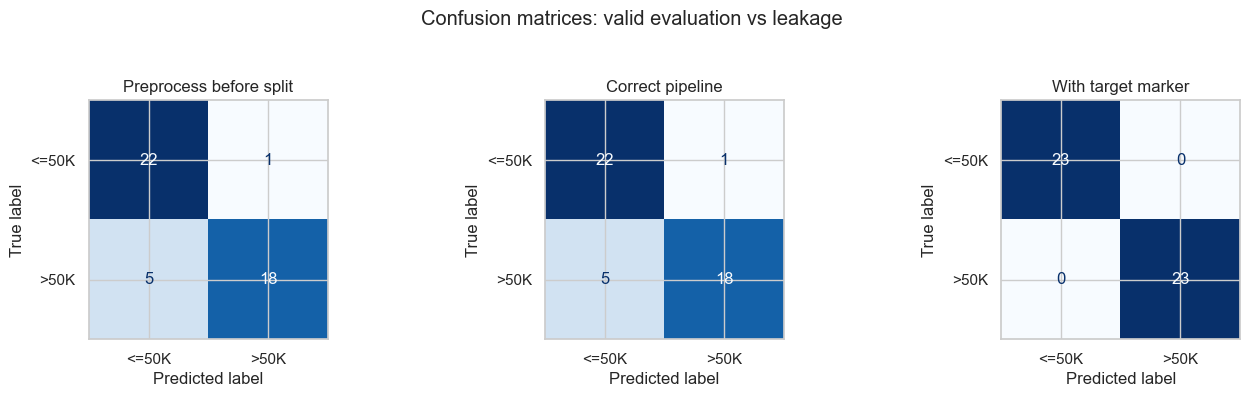

In [10]:
prediction_sets = {
    "Preprocess before split": leaky_predictions,
    "Correct pipeline": correct_predictions,
    "With target marker": marker_predictions,
}

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for axis, (name, predicted) in zip(axes, prediction_sets.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predicted,
        display_labels=["<=50K", ">50K"],
        cmap="Blues",
        colorbar=False,
        ax=axis,
    )
    axis.set_title(name)
plt.suptitle("Confusion matrices: valid evaluation vs leakage", y=1.04)
plt.tight_layout()
plt.show()

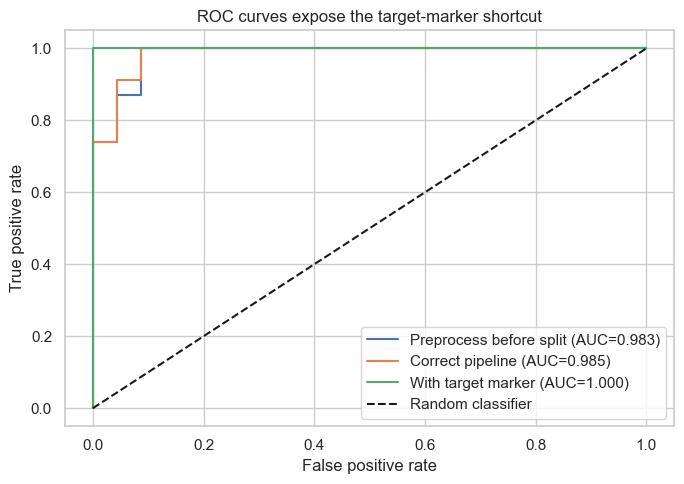

In [11]:
fig, ax = plt.subplots(figsize=(7, 5))
probability_sets = {
    "Preprocess before split": leaky_probabilities,
    "Correct pipeline": correct_probabilities,
    "With target marker": marker_probabilities,
}

for name, probabilities in probability_sets.items():
    false_positive_rate, true_positive_rate, _ = roc_curve(y_test, probabilities)
    auc = roc_auc_score(y_test, probabilities)
    ax.plot(false_positive_rate, true_positive_rate, label=f"{name} (AUC={auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", label="Random classifier")
ax.set(
    title="ROC curves expose the target-marker shortcut",
    xlabel="False positive rate",
    ylabel="True positive rate",
)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Checks

In [12]:
assert set(train_indices).isdisjoint(test_indices), "Train/test row overlap detected"
assert marker_agreement == 1.0, "The marker is not an exact target copy as expected"
assert "income_marker" not in X_train.columns, "The valid feature set contains the leaked marker"
assert correct_pipeline.named_steps["preprocess"].n_features_in_ == X_train.shape[1]

print("Checks passed:")
print("- train and test row indices are disjoint")
print("- the valid pipeline excludes income_marker")
print("- income_marker exactly reproduces the target and is correctly identified as leakage")

Checks passed:
- train and test row indices are disjoint
- the valid pipeline excludes income_marker
- income_marker exactly reproduces the target and is correctly identified as leakage


## Takeaways and Next Steps

- The valid pipeline achieved **87.0% accuracy** and **0.985 ROC AUC** on the held-out rows.
- Preprocessing before the split happened to produce the same accuracy on this small dataset, but the workflow remains invalid because the preprocessing learned from test rows.
- Adding `income_marker` produced **100% on every recorded metric**. That result is a warning sign, not a better model: the feature exactly reveals the target.
- Split raw observations before fitting imputers, encoders, scalers, feature selectors, or resampling steps.
- Put preprocessing inside a pipeline so cross-validation and final evaluation fit transformations only on training folds.
- Audit feature provenance. A technically correct pipeline still gives invalid results when a feature such as `income_marker` contains information derived from the answer.
- Treat the marker-based score as a demonstration of leakage, never as evidence of deployable model quality.